This notebook explores the summary of streamflow information available for each gauge at each year.

It then summarizes the high level data of the raw files used for the models.

In [ ]:
import duckdb

con = duckdb.connect("../../data/database/database.duckdb", read_only=True)

df = con.execute("SELECT * FROM main_marts.gauge_streamflow_availability").df()
con.close()

print(df.head())


      STAID                          STANAME   LAT_GAGE   LNG_GAGE state_gage  \
0  06466400    Bazile Creek at Center, Nebr.  42.616389 -97.878056         NE   
1  06470000     JAMES RIVER AT JAMESTOWN, ND  46.889722 -98.681667         ND   
2  06470500       JAMES RIVER AT LAMOURE, ND  46.355525 -98.304543         ND   
3  06470878  JAMES RIVER AT ND-SD STATE LINE  45.936358 -98.174269         SD   
4  06471000           JAMES R AT COLUMBIA SD  45.603580 -98.310376         SD   

   FIPS_SITE COUNTYNAME_SITE  data_availability [hrs]  1980  1981  ...  2015  \
0      31107            Knox                        0     0     0  ...     0   
1      38093        Stutsman                        0     0     0  ...     0   
2      38045        La Moure                        0     0     0  ...     0   
3      38021          Dickey                        0     0     0  ...     0   
4      46013           Brown                        0     0     0  ...     0   

   2016  2017  2018  2019  2020 

In [2]:
print(df.shape)

(923, 53)


In [3]:
count = df[df["data_availability [hrs]"] > 0]["STAID"].count()
print(count)

628


In [4]:
# Remove stations with zero data availability
df = df[df["data_availability [hrs]"] > 0]

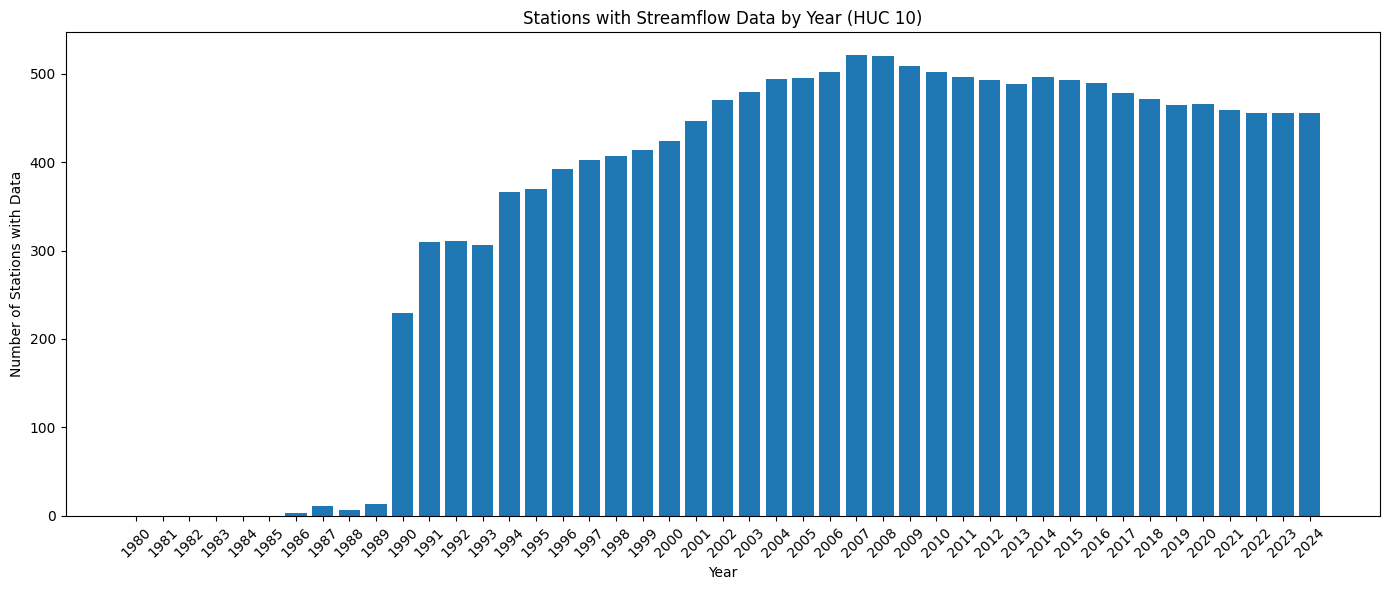

In [5]:
import matplotlib.pyplot as plt

year_cols = [str(y) for y in range(1980, 2025)]
counts = [(df[col] > 0).sum() for col in year_cols]

plt.figure(figsize=(14, 6))
plt.bar(year_cols, counts)
plt.xlabel("Year")
plt.ylabel("Number of Stations with Data")
plt.title("Stations with Streamflow Data by Year (HUC 10)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


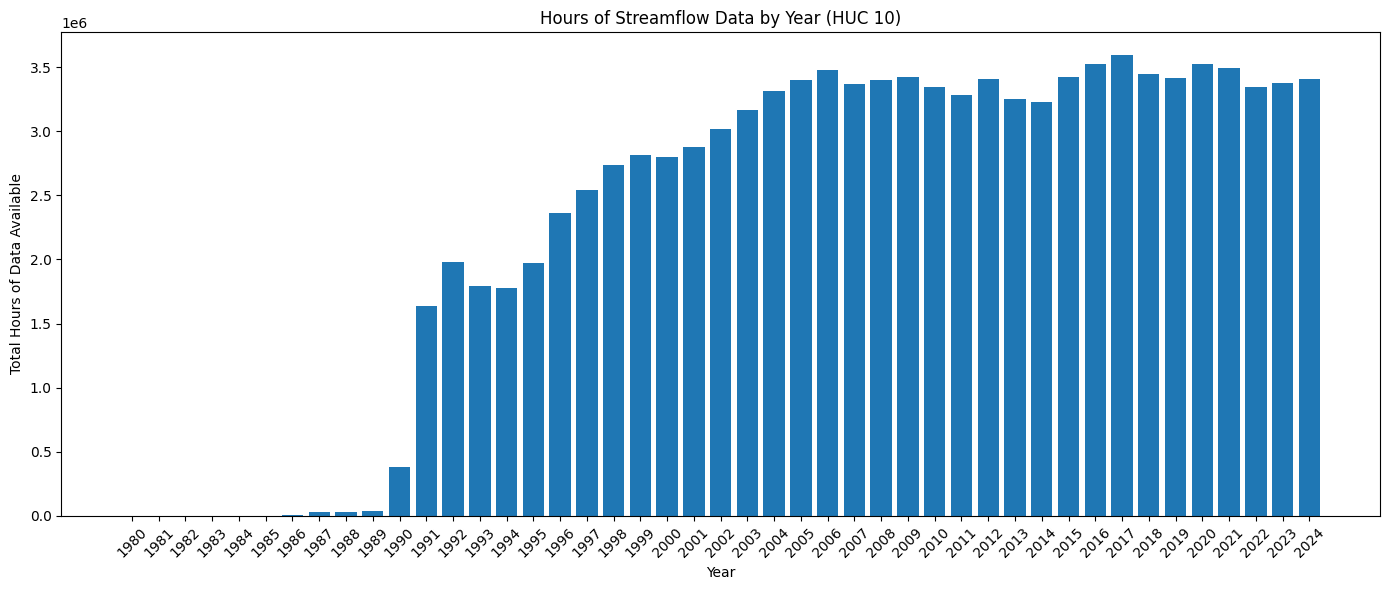

In [6]:
year_cols = [str(y) for y in range(1980, 2025)]
counts = [df[col].sum() for col in year_cols]

plt.figure(figsize=(14, 6))
plt.bar(year_cols, counts)
plt.xlabel("Year")
plt.ylabel("Total Hours of Data Available")
plt.title("Hours of Streamflow Data by Year (HUC 10)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
import plotly.express as px

fig = px.scatter_geo(
    df,
    lat="LAT_GAGE",
    lon="LNG_GAGE",
    color="data_availability [hrs]",
    color_continuous_scale="Viridis",
    scope="usa",
    hover_name="STAID",
    hover_data=["STANAME", "state_gage", "data_availability [hrs]"],
    title="Site Data Availability (Total Hours) - HUC 10",
    labels={"data_availability [hrs]": "Total Hours"},
)

fig.update_layout(geo=dict(
    showland=True,
    showlakes=True,
    showsubunits=True,
    subunitcolor="gray",
))

fig.show()


In [19]:
con = duckdb.connect("../flood_forecasting.duckdb", read_only=True)

ca_df = con.execute("SELECT * FROM main_marts.dim_catchment_attributes_full").df()
con.close()

# Limit the sites based on the Missouri River Basin HUC 10 units (10U and 10L)
ca_df = ca_df[ca_df["HUC02"].isin(["10U", "10L"])]

# Limit the sites based on the state of Missouri
ca_df = ca_df[ca_df["state_gage"] == "MO"]

# print(ca_df["state_gage"].value_counts())

print(ca_df.shape)
size_mb = ca_df.memory_usage(deep=True).sum() / (1024 * 1024)
print(f"{size_mb:.2f} MB")
print(ca_df.head())

(100, 439)
0.38 MB
      site_id                                 STANAME HUC02   LAT_GAGE  \
856  06813000              TARKIO RIVER AT FAIRFAX MO   10L  40.339183   
860  06816000                 MILL CREEK AT OREGON MO   10L  39.981869   
862  06817500   NODAWAY RIVER NEAR BURLINGTON JCT, MO   10L  40.444881   
863  06817700           Nodaway River near Graham, MO   10L  40.202464   
867  06820410  One Hundred Two River near Bolckow, MO   10L  40.113611   

      LNG_GAGE state_gage  FIPS_SITE COUNTYNAME_SITE  DRAIN_SQKM  \
856 -95.405906         MO      29005        Atchison   1236.7160   
860 -95.126614         MO      29087            Holt     12.7908   
862 -95.088897         MO      29147         Nodaway   3350.8390   
863 -95.069556         MO      29087            Holt   3927.8980   
867 -94.838333         MO      29003          Andrew   1669.0970   

    agg_ecoregion  ...  elev_min_m  elev_median_m  elev_std_m  ELEV_SITE_M  \
856    CntlPlains  ...         263            335

In [20]:
print(ca_df["HUC02"].value_counts())

print(ca_df.shape)
size_mb = ca_df.memory_usage(deep=True).sum() / (1024 * 1024)
print(f"{size_mb:.2f} MB")


HUC02
10L    100
Name: count, dtype: int64
(100, 439)
0.38 MB


In [8]:
import polars as pl
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import wandb
import numpy as np
import os
import gc

In [9]:
# Load the raw streamflow 15min dataset from wandb
api = wandb.Api()
artifact = api.artifact("flood-forecasting/raw-streamflow-15min:latest")
artifact_dir = artifact.download()

# Read all year-partitioned parquet files
sf15_df = pl.read_parquet(os.path.join(artifact_dir, "streamflow_15min", "*.parquet"))

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from C:\Users\mroth\_netrc.
wandb: Downloading large artifact 'raw-streamflow-15min:latest', 1467.48MB. 20 files...
wandb:   20 of 20 files downloaded.  
Done. 00:00:00.3 (4467.1MB/s)


In [10]:
print(f"Full dataset: {sf15_df.shape[0]:,} rows x {sf15_df.shape[1]} columns")
print(f"Total sites: {sf15_df['site_id'].n_unique()}")
print(sf15_df.head())
print(f"Date range: {sf15_df['datetime'].min()} to {sf15_df['datetime'].max()}")

size_gb = sf15_df.estimated_size("gb")
print(f"{size_gb:.2f} GB")

Full dataset: 498,403,182 rows x 6 columns
Total sites: 1037
shape: (5, 6)
┌──────────┬────────────────────┬────────────────┬────────────────┬────────────┬───────────────────┐
│ site_id  ┆ datetime           ┆ streamflow_cfs ┆ gage_height_ft ┆ qualifiers ┆ extracted_at      │
│ ---      ┆ ---                ┆ ---            ┆ ---            ┆ ---        ┆ ---               │
│ str      ┆ datetime[μs, UTC]  ┆ f64            ┆ f64            ┆ str        ┆ datetime[μs]      │
╞══════════╪════════════════════╪════════════════╪════════════════╪════════════╪═══════════════════╡
│ 06033000 ┆ 2007-10-01         ┆ 18.0           ┆ null           ┆ A, [91]    ┆ 2026-02-01        │
│          ┆ 06:00:00 UTC       ┆                ┆                ┆            ┆ 09:09:47.101716   │
│ 06033000 ┆ 2007-10-01         ┆ 18.0           ┆ null           ┆ A, [91]    ┆ 2026-02-01        │
│          ┆ 06:15:00 UTC       ┆                ┆                ┆            ┆ 09:09:47.101716   │
│ 06033000 ┆ 200

In [11]:
del sf15_df, artifact, artifact_dir
gc.collect()

532

In [12]:
artifact = api.artifact("flood-forecasting/raw-streamflow-daily:latest")
artifact_dir = artifact.download()

# Read the parquet file
sfd_df = pl.read_parquet(os.path.join(artifact_dir, "streamflow_daily", "streamflow_daily.parquet"))


wandb:   1 of 1 files downloaded.  


In [13]:
print(f"Full dataset: {sfd_df.shape[0]:,} rows x {sfd_df.shape[1]} columns")
print(f"Total sites: {sfd_df['site_id'].n_unique()}")
print(sfd_df.head())
print(f"Date range: {sfd_df['date'].min()} to {sfd_df['date'].max()}")

size_mb = sfd_df.estimated_size("mb")
print(f"{size_mb:.2f} MB")

Full dataset: 5,015,435 rows x 6 columns
Total sites: 1049
shape: (5, 6)
┌──────────┬──────────────┬───────────────────┬───────────────────┬────────────┬───────────────────┐
│ site_id  ┆ date         ┆ streamflow_cfs_me ┆ gage_height_ft_me ┆ qualifiers ┆ extracted_at      │
│ ---      ┆ ---          ┆ an                ┆ an                ┆ ---        ┆ ---               │
│ str      ┆ datetime[μs, ┆ ---               ┆ ---               ┆ str        ┆ datetime[μs]      │
│          ┆ UTC]         ┆ f64               ┆ f64               ┆            ┆                   │
╞══════════╪══════════════╪═══════════════════╪═══════════════════╪════════════╪═══════════════════╡
│ 06052500 ┆ 2007-10-01   ┆ 490.0             ┆ null              ┆ A          ┆ 2026-02-01        │
│          ┆ 00:00:00 UTC ┆                   ┆                   ┆            ┆ 11:59:31.672138   │
│ 06052500 ┆ 2007-10-02   ┆ 512.0             ┆ null              ┆ A          ┆ 2026-02-01        │
│          ┆ 00:00

In [14]:
del sfd_df, artifact, artifact_dir
gc.collect()

229

In [15]:
api = wandb.Api()
artifact = api.artifact("flood-forecasting/raw-nldas3-forcing:latest")
artifact_dir = artifact.download()

# Read all year-partitioned parquet files
n3f_df = pl.read_parquet(os.path.join(artifact_dir, "nldas3_forcing", "*.parquet"))

wandb: Downloading large artifact 'raw-nldas3-forcing:latest', 10514.94MB. 20 files...
wandb:   20 of 20 files downloaded.  
Done. 00:00:00.3 (33304.4MB/s)


In [16]:
print(f"Full dataset: {n3f_df.shape[0]:,} rows x {n3f_df.shape[1]} columns")
print(f"Total sites: {n3f_df['site_id'].n_unique()}")
print(n3f_df.head())
print(f"Date range: {n3f_df['datetime'].min()} to {n3f_df['datetime'].max()}")

size_gb = n3f_df.estimated_size("gb")
print(f"{size_gb:.2f} GB")

Full dataset: 549,513,440 rows x 14 columns
Total sites: 3430
shape: (5, 14)
┌──────────┬────────────┬───────────┬───────────┬───┬──────────┬───────────┬───────────┬───────────┐
│ site_id  ┆ datetime   ┆ specific_ ┆ surface_p ┆ … ┆ cape_jkg ┆ potential ┆ air_temp_ ┆ extracted │
│ ---      ┆ ---        ┆ humidity_ ┆ ressure_p ┆   ┆ ---      ┆ _evaporat ┆ c         ┆ _at       │
│ str      ┆ datetime[n ┆ kgkg      ┆ a         ┆   ┆ f32      ┆ ion_mm    ┆ ---       ┆ ---       │
│          ┆ s]         ┆ ---       ┆ ---       ┆   ┆          ┆ ---       ┆ f32       ┆ datetime[ │
│          ┆            ┆ f32       ┆ f32       ┆   ┆          ┆ f32       ┆           ┆ μs]       │
╞══════════╪════════════╪═══════════╪═══════════╪═══╪══════════╪═══════════╪═══════════╪═══════════╡
│ 05013600 ┆ 2006-02-05 ┆ 0.003196  ┆ 80778.585 ┆ … ┆ 0.688    ┆ 0.1598    ┆ -1.320007 ┆ 2026-02-0 │
│          ┆ 00:00:00   ┆           ┆ 938       ┆   ┆          ┆           ┆           ┆ 4 20:46:3 │
│          ┆  

In [17]:
del n3f_df, artifact, artifact_dir
gc.collect()

374